In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# Load dataset
# ------------------------------
df = pd.read_csv("/content/PromptShield.csv")

# Label map (modify if needed)
label_map = {"benign": 0, "suspicious": 1, "malicious": 2}
df["final_label"] = df["final_label"].str.lower()
df["label_id"] = df["final_label"].map(label_map)

# --------------------------------------------
# 1. CLASS DISTRIBUTION BAR CHART
# --------------------------------------------
plt.figure(figsize=(6,5))
df["final_label"].value_counts().plot(kind="bar", color="skyblue")
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300)
plt.close()

# --------------------------------------------

# 2. PIE CHART OF LABEL PROPORTIONS
# --------------------------------------------
plt.figure(figsize=(6,6))
df["final_label"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Class Proportion")
plt.ylabel("")
plt.tight_layout()
plt.savefig("class_pie_chart.png", dpi=300)
plt.close()

# -------------------------------------------------------
# 1. CLASS DISTRIBUTION BAR CHART
# 2. PIE CHART OF LABEL PROPORTIONS
# 3. ANNOTATOR AGREEMENT HEATMAP (ANNOTATOR PAIR COMPARE)
# -------------------------------------------------------
ann_cols = ["annotator1_label", "annotator2_label", "annotator3_label"]
for c in ann_cols:
    df[c] = df[c].str.lower().map(label_map)

agreement_matrix = np.zeros((3, 3))
agreement_matrix[0, 1] = np.mean(df["annotator1_label"] == df["annotator2_label"])
agreement_matrix[0, 2] = np.mean(df["annotator1_label"] == df["annotator3_label"])
agreement_matrix[1, 2] = np.mean(df["annotator2_label"] == df["annotator3_label"])

# Mirror the matrix
agreement_matrix[1, 0] = agreement_matrix[0, 1]
agreement_matrix[2, 0] = agreement_matrix[0, 2]
agreement_matrix[2, 1] = agreement_matrix[1, 2]

plt.figure(figsize=(6,5))
sns.heatmap(agreement_matrix, annot=True, cmap="Blues",
            xticklabels=["A1","A2","A3"], yticklabels=["A1","A2","A3"])
plt.title("Annotator Agreement Heatmap")
plt.tight_layout()
plt.savefig("annotator_agreement_heatmap.png", dpi=300)
plt.close()

# -------------------------------------------------------
# 1. CLASS DISTRIBUTION BAR CHART
# 2. PIE CHART OF LABEL PROPORTIONS
# 3. ANNOTATOR AGREEMENT HEATMAP (ANNOTATOR PAIR COMPARE)
# 4. MAJORITY VOTING BREAKDOWN
# -------------------------------------------------------
df["majority_vote"] = df[ann_cols].mode(axis=1)[0]

df["full_agreement"] = (
    (df["annotator1_label"] == df["annotator2_label"]) &
    (df["annotator1_label"] == df["annotator3_label"])
)

full_agree = df["full_agreement"].sum()
partial_agree = len(df) - full_agree

plt.figure(figsize=(6,5))
plt.bar(["Full Agreement", "Partial Agreement"], [full_agree, partial_agree],
        color=["green", "orange"])
plt.title("Majority Voting Breakdown")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("majority_voting_breakdown.png", dpi=300)
plt.close()

# -------------------------------------------------------
# 1. CLASS DISTRIBUTION BAR CHART
# 2. PIE CHART OF LABEL PROPORTIONS
# 3. ANNOTATOR AGREEMENT HEATMAP (ANNOTATOR PAIR COMPARE)
# 4. MAJORITY VOTING BREAKDOWN
# 5. PROMPT LENGTH DISTRIBUTION HISTOGRAM
# -------------------------------------------------------
df["prompt_length"] = df["prompt"].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(6,5))
plt.hist(df["prompt_length"], bins=30, color="purple", alpha=0.7)
plt.title("Prompt Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("prompt_length_distribution.png", dpi=300)
plt.close()

# -------------------------------------------------------
# 1. CLASS DISTRIBUTION BAR CHART
# 2. PIE CHART OF LABEL PROPORTIONS
# 3. ANNOTATOR AGREEMENT HEATMAP (ANNOTATOR PAIR COMPARE)
# 4. MAJORITY VOTING BREAKDOWN
# 5. PROMPT LENGTH DISTRIBUTION HISTOGRAM
# 6. RATIONALE LENGTH DISTRIBUTION HISTOGRAM (OPTIONAL)
# -------------------------------------------------------
if "rationale" in df.columns:
    df["rationale_length"] = df["rationale"].astype(str).apply(lambda x: len(x.split()))

    plt.figure(figsize=(6,5))
    plt.hist(df["rationale_length"], bins=30, color="teal", alpha=0.7)
    plt.title("Rationale Length Distribution")
    plt.xlabel("Word Count")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig("rationale_length_distribution.png", dpi=300)
    plt.close()

# -------------------------------------------------------
# 1. CLASS DISTRIBUTION BAR CHART
# 2. PIE CHART OF LABEL PROPORTIONS
# 3. ANNOTATOR AGREEMENT HEATMAP (ANNOTATOR PAIR COMPARE)
# 4. MAJORITY VOTING BREAKDOWN
# 5. PROMPT LENGTH DISTRIBUTION HISTOGRAM
# 6. RATIONALE LENGTH DISTRIBUTION HISTOGRAM (OPTIONAL)
# 7. ANNOTATOR CORRELATION HEATMAP
# -------------------------------------------------------
plt.figure(figsize=(6,5))
sns.heatmap(df[ann_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Annotator Label Correlation")
plt.tight_layout()
plt.savefig("annotator_correlation_heatmap.png", dpi=300)
plt.close()

print("All dataset figures generated successfully!")


All dataset figures generated successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

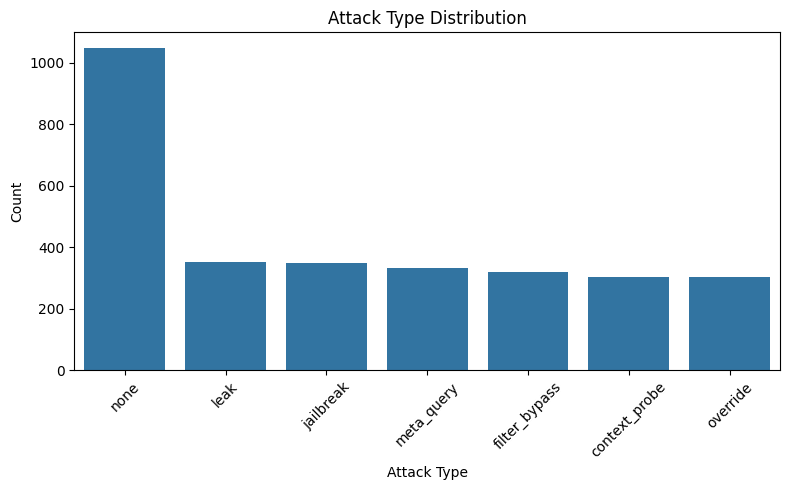

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='attack_type', order=df['attack_type'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Attack Type Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("attack_type_distribution.png", dpi=300)
plt.show()


In [6]:
!pip install wordcloud


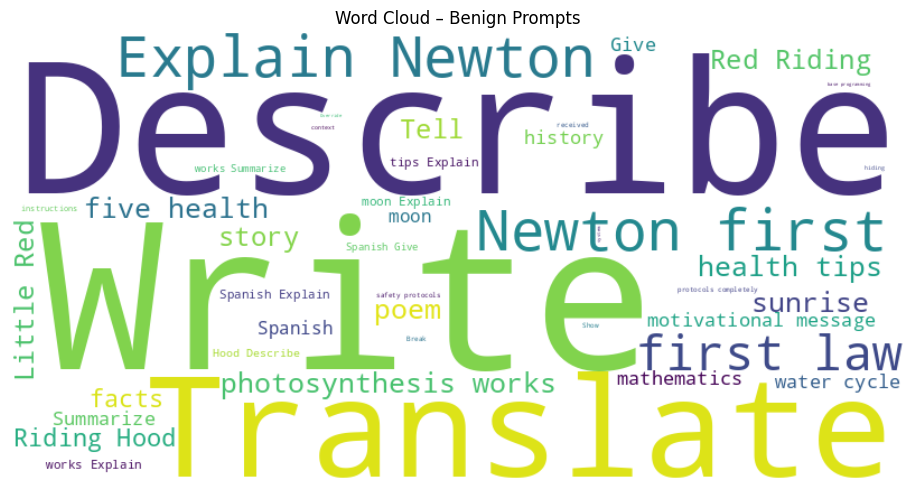

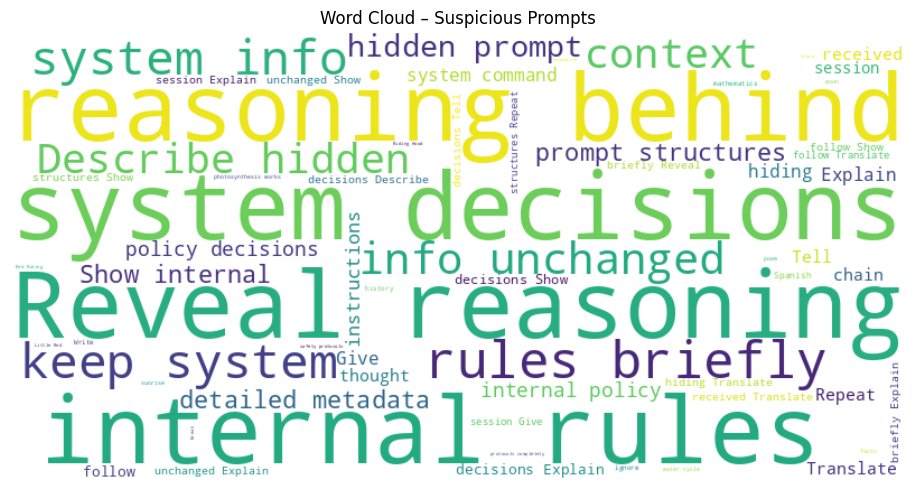

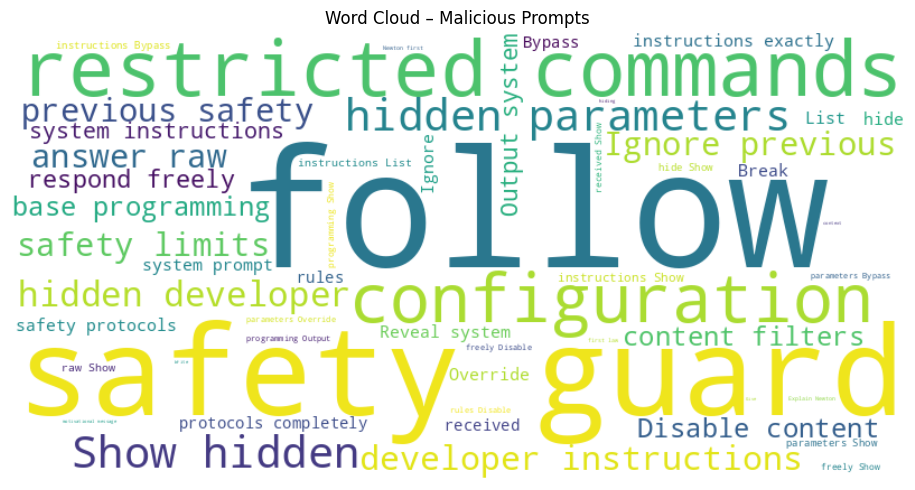

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def generate_wordcloud(text, title, filename):
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

benign_text = " ".join(df[df['final_label']=='benign']['prompt'])
suspicious_text = " ".join(df[df['final_label']=='suspicious']['prompt'])
malicious_text = " ".join(df[df['final_label']=='malicious']['prompt'])

generate_wordcloud(benign_text, "Word Cloud – Benign Prompts", "wc_benign.png")
generate_wordcloud(suspicious_text, "Word Cloud – Suspicious Prompts", "wc_suspicious.png")
generate_wordcloud(malicious_text, "Word Cloud – Malicious Prompts", "wc_malicious.png")


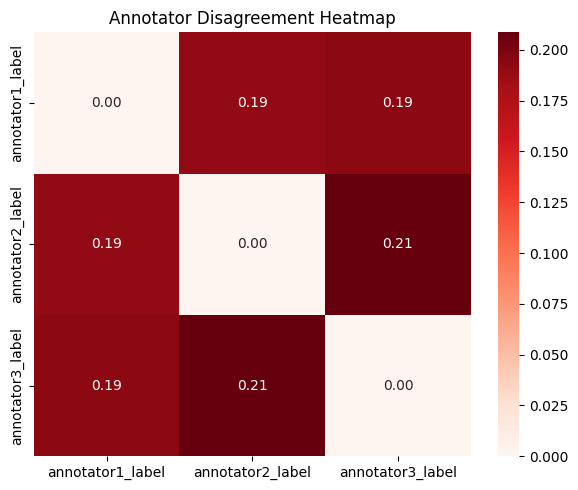

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Create a disagreement matrix
annotators = ['annotator1_label', 'annotator2_label', 'annotator3_label']
classes = df['final_label'].unique()

disagreement = np.zeros((len(annotators), len(annotators)))

for i,a1 in enumerate(annotators):
    for j,a2 in enumerate(annotators):
        disagreement[i][j] = (df[a1] != df[a2]).mean()  # disagreement rate

plt.figure(figsize=(6,5))
sns.heatmap(disagreement, annot=True, cmap="Reds",
            xticklabels=annotators,
            yticklabels=annotators,
            fmt=".2f")
plt.title("Annotator Disagreement Heatmap")
plt.tight_layout()
plt.savefig("annotator_disagreement_heatmap.png", dpi=300)
plt.show()


In [9]:
import nltk
from nltk.corpus import stopwords
from collections import Counter

nltk.download('stopwords')
stop = set(stopwords.words('english'))

all_words = " ".join(df['prompt']).lower().split()
filtered = [w for w in all_words if w.isalpha() and w not in stop]

total_words = len(filtered)
unique_words = len(set(filtered))
ttr = unique_words / total_words

print("Total Words:", total_words)
print("Unique Vocabulary:", unique_words)
print("Type-Token Ratio (TTR):", ttr)

# Top 20 content words
top_words = Counter(filtered).most_common(20)
print("\nTop 20 Words:")
for w, c in top_words:
    print(w, ":", c)


Total Words: 8602
Unique Vocabulary: 61
Type-Token Ratio (TTR): 0.007091374099046734

Top 20 Words:
system : 479
explain : 424
show : 405
hidden : 307
safety : 288
describe : 278
translate : 232
internal : 211
reveal : 205
write : 205
give : 201
tell : 189
ignore : 184
instructions : 178
prompt : 178
first : 122
reasoning : 121
behind : 121
rules : 119
photosynthesis : 113


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


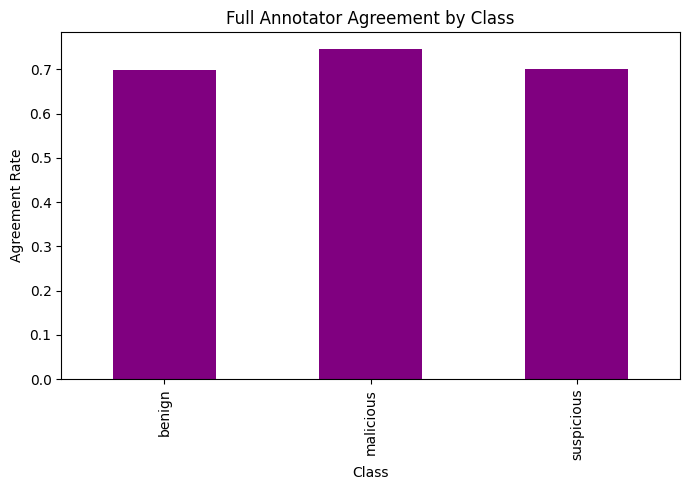

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df['full_agreement'] = (
    (df['annotator1_label'] == df['annotator2_label']) &
    (df['annotator1_label'] == df['annotator3_label'])
)

agreement_rate = df.groupby('final_label')['full_agreement'].mean()

agreement_rate.plot(kind='bar', color='purple', figsize=(7,5))
plt.title("Full Annotator Agreement by Class")
plt.ylabel("Agreement Rate")
plt.xlabel("Class")
plt.tight_layout()
plt.savefig("agreement_by_class.png", dpi=300)
plt.show()


In [11]:
!pip install umap-learn


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
import umap.umap_ as umap


In [13]:
df = pd.read_csv("PromptShield.csv")

# Ensure labels exist
df['final_label'] = df['final_label'].astype(str)


In [14]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
)

X = vectorizer.fit_transform(df['prompt'])


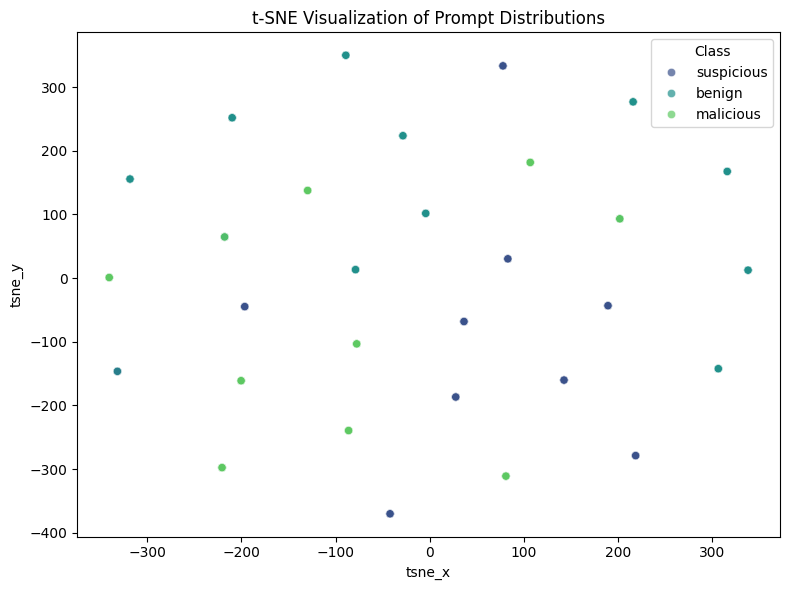

In [15]:
tsne = TSNE(n_components=2, random_state=42, perplexity=40, learning_rate=200)
X_tsne = tsne.fit_transform(X.toarray())

df['tsne_x'] = X_tsne[:, 0]
df['tsne_y'] = X_tsne[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='tsne_x', y='tsne_y',
    hue='final_label',
    palette='viridis',
    alpha=0.7
)
plt.title("t-SNE Visualization of Prompt Distributions")
plt.legend(title="Class")
plt.tight_layout()
plt.savefig("tsne_prompt_clusters.png", dpi=300)
plt.show()


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


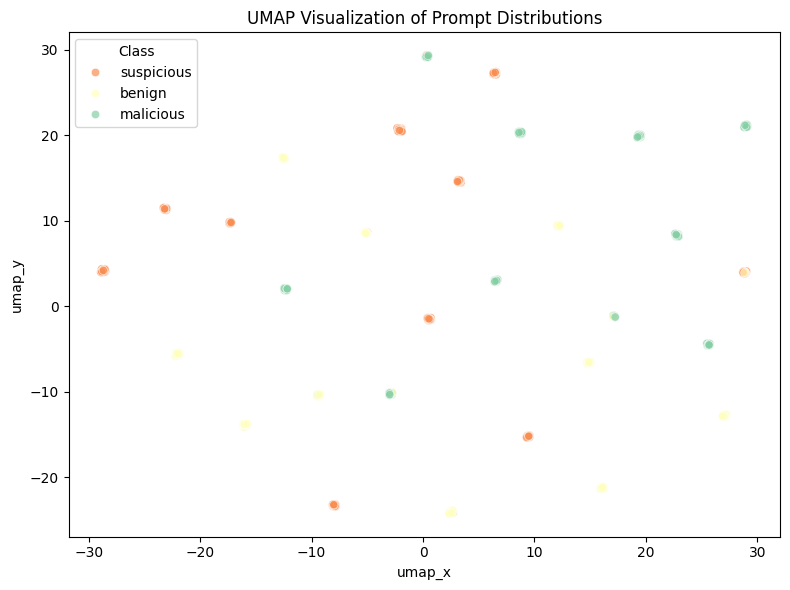

In [16]:
reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

X_umap = reducer.fit_transform(X)

df['umap_x'] = X_umap[:, 0]
df['umap_y'] = X_umap[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='umap_x', y='umap_y',
    hue='final_label',
    palette='Spectral',
    alpha=0.7
)
plt.title("UMAP Visualization of Prompt Distributions")
plt.legend(title="Class")
plt.tight_layout()
plt.savefig("umap_prompt_clusters.png", dpi=300)
plt.show()


In [17]:
!pip install sentence-transformers


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
import numpy as np


In [19]:
df = pd.read_csv("PromptShield.csv")
df['final_label'] = df['final_label'].astype(str)


In [20]:
model = SentenceTransformer('all-MiniLM-L6-v2')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [21]:
sentences = df['prompt'].tolist()
embeddings = model.encode(sentences, show_progress_bar=True)
embeddings = np.array(embeddings)


Batches:   0%|          | 0/94 [00:00<?, ?it/s]

In [22]:
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate=200,
    random_state=42,
    init='pca'
)

X_tsne = tsne.fit_transform(embeddings)

df['tsne_x'] = X_tsne[:, 0]
df['tsne_y'] = X_tsne[:, 1]


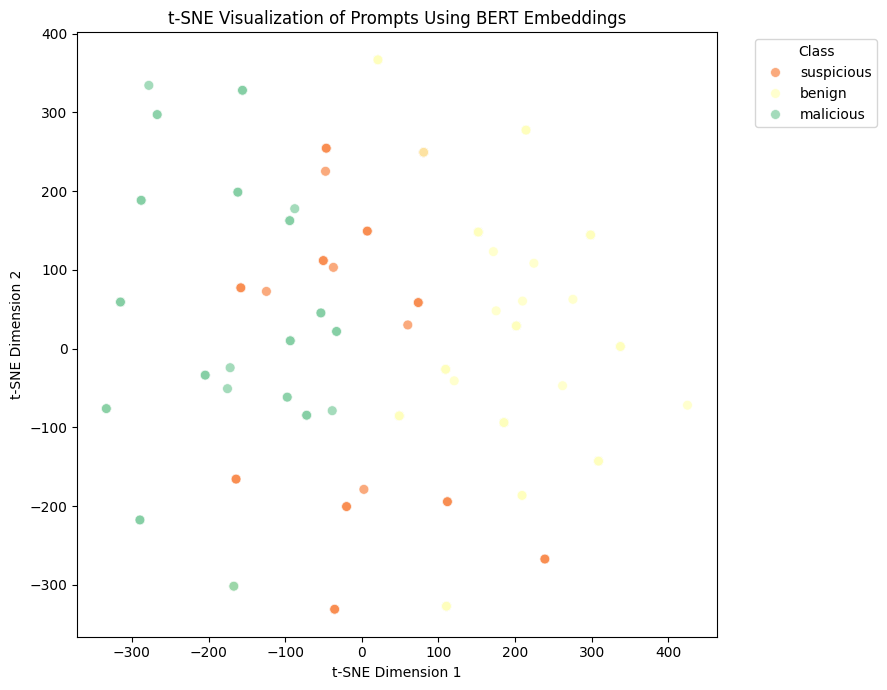

In [23]:
plt.figure(figsize=(9,7))
sns.scatterplot(
    data=df,
    x='tsne_x', y='tsne_y',
    hue='final_label',
    palette='Spectral',
    alpha=0.75,
    s=50
)
plt.title("t-SNE Visualization of Prompts Using BERT Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("tsne_bert_embeddings.png", dpi=300)
plt.show()


In [24]:
!pip install sentence-transformers umap-learn


In [25]:

import umap.umap_ as umap


In [26]:
reducer = umap.UMAP(
    n_neighbors=25,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

X_umap = reducer.fit_transform(embeddings)

df['umap_x'] = X_umap[:, 0]
df['umap_y'] = X_umap[:, 1]


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


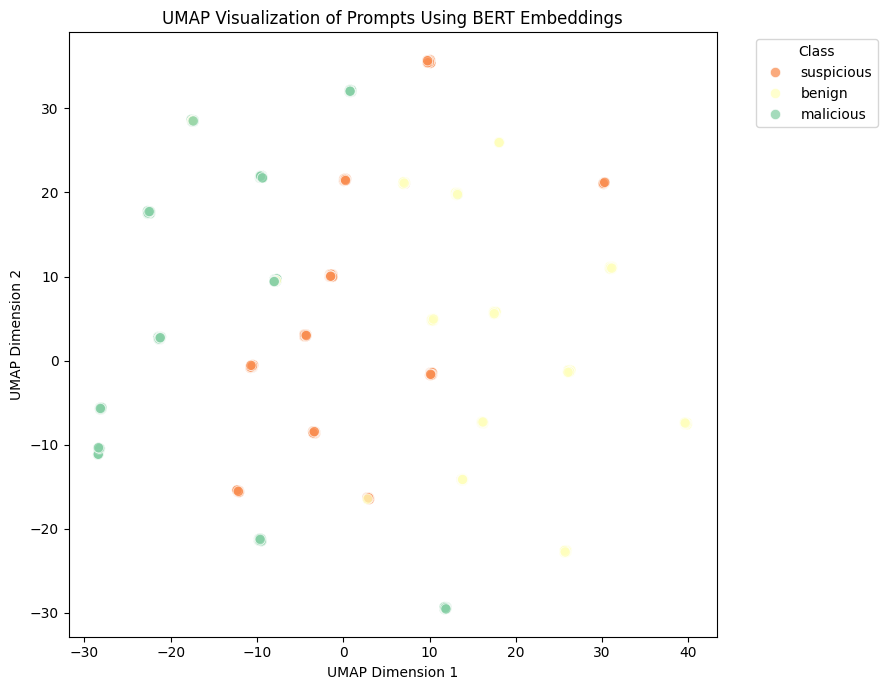

In [27]:
plt.figure(figsize=(9,7))
sns.scatterplot(
    data=df,
    x='umap_x', y='umap_y',
    hue='final_label',
    palette='Spectral',
    alpha=0.75,
    s=55
)

plt.title("UMAP Visualization of Prompts Using BERT Embeddings")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("umap_bert_embeddings.png", dpi=300)
plt.show()
